# Trabalho de Grupo — Modelos de Regressão
## Previsão de Preços Airbnb em Valência

**Licenciatura em Ciência de Dados — ISCTE 2025/26**
**Dataset:** Inside Airbnb Valência, snapshot 2025-09-23 (`listings.csv`, 7 844 × 18)

Este notebook segue a metodologia **CRISP-DM** e está organizado em 7 secções:
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modelling
5. Validação dos pressupostos
6. Avaliação dos resultados
7. Referências

**Executar AS-IS** com `jupyter nbconvert --to notebook --execute Trabalho_v2.ipynb`.


## 0. Setup

Instalação de dependências, imports e configuração global.

In [38]:
# Instalação silenciosa das dependências (descomenta se for a primeira vez)
# %pip install -q pandas numpy matplotlib seaborn scikit-learn statsmodels scipy openpyxl geopandas wquantiles contextily


In [39]:
# -------- Imports consolidados (sem duplicados) --------
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2, shapiro
from scipy.spatial.distance import mahalanobis

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# -------- Config global --------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 90

# -------- Pastas de output --------
os.makedirs("outputs", exist_ok=True)

print("Setup concluído. RANDOM_STATE =", RANDOM_STATE)


Setup concluído. RANDOM_STATE = 42


---
# 1. Business Understanding

## 1.1 Contexto

O Airbnb é uma das maiores plataformas de alojamento de curta duração do mundo. A cidade de **Valência (Espanha)** é um destino turístico em crescimento acelerado, com forte sazonalidade (praia, Fallas, ciclo mediterrânico). Os dados foram obtidos do projecto [Inside Airbnb](http://insideairbnb.com/get-the-data/), que disponibiliza dumps públicos da oferta visível no site, com periodicidade ~trimestral. O snapshot usado é de **23 de setembro de 2025**.

A versão descarregada corresponde ao ficheiro `listings.csv` (versão resumida de 18 colunas). Esta é a versão que o enunciado indica explicitamente: *«Apenas fazer o download do ficheiro listings.csv da cidade do seu grupo.»*

## 1.2 Problema de negócio

**Objectivo:** construir um modelo de regressão que permita **estimar o preço por noite** (variável `price`) de um alojamento Airbnb em Valência, a partir das restantes variáveis disponíveis.

## 1.3 Questões de investigação

- **Q1.** Até que ponto o *tipo de alojamento* (`room_type`) explica a variação de preço?
- **Q2.** A *localização* (bairro, cluster geográfico, latitude/longitude) tem um efeito marginal sobre o preço para além do tipo?
- **Q3.** O *perfil do anfitrião* (número de listings gerido, `calculated_host_listings_count`) está associado a preços mais altos (oferta profissional) ou mais baixos (concorrência)?
- **Q4.** As *políticas de reserva* (`minimum_nights`, `availability_365`) têm efeito no preço?
- **Q5.** A *actividade passada* (número e ritmo de reviews) está correlacionada com preço?

## 1.4 Justificação das variáveis

| Papel | Variáveis | Razão |
|---|---|---|
| **Dependente** | `price` (log-transformado) | Alvo do modelo; log porque a distribuição é fortemente assimétrica |
| **Categóricas** | `room_type`, `neighbourhood_group` (ou clusters K-Means) | Efeito de tipo/localização |
| **Numéricas** | `minimum_nights` (log), `availability_365` → `availability_rate`, `calculated_host_listings_count`, `number_of_reviews_ltm`, `reviews_per_month` | Perfil de oferta e aceitação |
| **Derivadas** | `log_price`, `log_minimum_nights`, `availability_rate`, `days_since_last_review`, `license_exists`, `has_reviews`, `profissional` | Capturam não-linearidades e missings |
| **Excluídas** | `id`, `host_id`, `name`, `host_name`, `last_review`, `license` (bruta), `latitude/longitude` brutas | Identificadores, texto livre, ou substituídas por derivadas |

## 1.5 Limitações do dataset

O ficheiro resumido tem **apenas 18 colunas**. Variáveis conceptualmente decisivas para o preço — **número de quartos (`bedrooms`), casas-de-banho (`bathrooms`), capacidade (`accommodates`), amenities, property_type, reviews scores** — estão ausentes. Na literatura de Hedonic Pricing (Lancaster 1966, Rosen 1974) estas são precisamente as features com maior poder explicativo. Isto significa que devemos esperar um **R² baixo** em qualquer modelo construído sobre estas 18 colunas — o limite superior da performance está intrinsecamente baixo.

## 1.6 Critérios de sucesso

- Pipeline que corre end-to-end sem erros.
- Tratamento explícito dos missings, outliers e assimetrias.
- Pelo menos 4 famílias de modelo treinadas e comparadas.
- Validação dos pressupostos clássicos sobre o conjunto de teste.
- Interpretação crítica dos resultados à luz das limitações do dataset.


---
# 2. Data Understanding

Carregamento do dataset, inspecção de estrutura, estatísticas descritivas, correlações e análise de qualidade.


## 2.1 Leitura do dataset

In [40]:
# Carregar o ficheiro listings.csv (caminho relativo à pasta do notebook)
CAMINHO_DADOS = "dataset/listings.csv"
CAMINHO_OUTPUTS = "outputs/"
df = pd.read_csv(CAMINHO_DADOS)
# Conversão de last_review para datetime (errors=coerce mantém NA onde não é parseável)
df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")

print(f"Shape: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head(3)


Shape: 7844 linhas x 18 colunas


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,48154,Precioso apartamento con wifi,219476,Antonio,LA SAIDIA,MORVEDRE,39.48375,-0.37502,Entire home/apt,83.0,3,197,2025-09-15,1.08,4,150,26,VT-41540-V
1,137143,PENTHOUSE ON FRONT LINE BEACH,670775,Maria De La Piedad,POBLATS DEL SUD,EL SALER,39.36335,-0.31932,Entire home/apt,390.0,10,1,2013-07-02,0.01,5,20,0,VT32745V
2,149715,1900 Style Valencian Beach Home for 10px,5947,Susana Barbara,POBLATS MARITIMS,CABANYAL-CANYAMELAR,39.46746,-0.32813,Entire home/apt,245.0,2,313,2025-09-15,1.81,1,287,41,ESFCTU000046025000580569000000000000000000VT-3...


## 2.2 Tipos de dados e estrutura

In [41]:
# Classificação explícita das variáveis por tipo
quantitativa_discretas = [
    "number_of_reviews_ltm", "number_of_reviews",
    "minimum_nights", "calculated_host_listings_count"
]
quantitativa_continuas = [
    "latitude", "longitude", "price", "reviews_per_month", "availability_365"
]
qualitativas_nominais = [
    "neighbourhood_group", "neighbourhood", "host_name", "room_type", "name"
]
# id/host_id são identificadores, não categorias; tratamos como descartáveis sem os converter
identificadores = ["id", "host_id"]
texto_livre = ["license"]  # license é uma string longa; tratamos só a existência mais à frente

for col in qualitativas_nominais + texto_livre + identificadores:
    df[col] = df[col].astype("category")

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7844 entries, 0 to 7843
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              7844 non-null   category      
 1   name                            7844 non-null   category      
 2   host_id                         7844 non-null   category      
 3   host_name                       7838 non-null   category      
 4   neighbourhood_group             7844 non-null   category      
 5   neighbourhood                   7844 non-null   category      
 6   latitude                        7844 non-null   float64       
 7   longitude                       7844 non-null   float64       
 8   room_type                       7844 non-null   category      
 9   price                           6979 non-null   float64       
 10  minimum_nights                  7844 non-null   int64         
 11  numb

### 2.4 Range e valores das variáveis

In [42]:
# Função para range das variáveis
def range_variaveis(variaveis):
    dados_variaveis = []
    for col in variaveis:
        dados_variaveis.append({
            "Variável": col,
            "Amplitude": f" {df[col].min()}; {df[col].max()} "
        })
    return dados_variaveis
# Função para determinar os valores das variáveis qualitativas
def valores_qualitativas(variaveis):
    dados_variaveis = []
    for col in variaveis:
        categorias = df[col].cat.categories.tolist()
        dados_variaveis.append({
            "Variável": col,
            "Amplitude": None,
            "Categorias": ", ".join(map(str, categorias))
        })
    return dados_variaveis

dataframe_geral = []
dataframe_geral.extend(range_variaveis(quantitativa_continuas + quantitativa_discretas))
dataframe_geral.extend(valores_qualitativas(qualitativas_nominais+texto_livre+identificadores))
dataframe_geral = pd.DataFrame(dataframe_geral)
dataframe_geral

,Variável,Amplitude,Categorias
0,latitude,39.2799863; 39.54579,NaN
1,longitude,-0.42584; -0.27628,NaN
2,price,8.0; 40000.0,NaN
3,reviews_per_month,0.01; 37.71,NaN
4,availability_365,0; 365,NaN
5,number_of_reviews_ltm,0; 367,NaN
6,number_of_reviews,0; 935,NaN
7,minimum_nights,1; 366,NaN
8,calculated_host_listings_count,1; 103,NaN
9,neighbourhood_group,None,"ALGIROS, BENICALAP, BENIMACLET, CAMINS AL GRAU..."


## 2.3 Estatísticas descritivas — variáveis quantitativas

Função reutilizável que calcula média, mediana, std, IQR, assimetria e curtose. Coerente com o trabalho original, mas com nome corrigido e tratamento de NAs.

In [43]:
def describe_quantitativa(df, cols, export=False, export_name="descritivas.xlsx"):
    """Estatísticas descritivas completas para variáveis quantitativas."""
    desc = df[cols].describe().round(3)
    desc.loc["amplitude"] = (df[cols].max() - df[cols].min()).round(3)
    desc.loc["IQR"] = (df[cols].quantile(0.75) - df[cols].quantile(0.25)).round(3)
    desc.loc["assimetria"] = df[cols].skew().round(3)
    desc.loc["curtose"] = df[cols].kurtosis().round(3)
    if export:
        desc.to_excel(f"{CAMINHO_OUTPUTS}/{export_name}", index=True)
    display(desc)
    return desc

desc_cont = describe_quantitativa(df, quantitativa_continuas)


,latitude,longitude,price,reviews_per_month,availability_365
count,7844.000,7844.000,6979.000,6867.000,7844.000
mean,39.467,-0.364,164.113,1.695,185.951
std,0.019,0.023,732.639,1.666,120.086
min,39.280,-0.426,8.000,0.010,0.000
25%,39.461,-0.380,71.000,0.470,77.000
50%,39.469,-0.371,102.000,1.170,179.000
75%,39.475,-0.344,140.000,2.490,305.000
max,39.546,-0.276,40000.000,37.710,365.000
amplitude,0.266,0.150,39992.000,37.700,365.000
IQR,0.013,0.036,69.000,2.020,228.000


In [44]:
# Estatísticas das discretas também
desc_disc = describe_quantitativa(df, quantitativa_discretas)


,number_of_reviews_ltm,number_of_reviews,minimum_nights,calculated_host_listings_count
count,7844.000,7844.000,7844.000,7844.000
mean,13.353,51.636,6.554,12.325
std,17.752,86.940,18.756,20.771
min,0.000,0.000,1.000,1.000
25%,1.000,3.000,1.000,1.000
50%,6.000,16.000,2.000,3.000
75%,21.000,58.250,5.000,11.000
max,367.000,935.000,366.000,103.000
amplitude,367.000,935.000,365.000,102.000
IQR,20.000,55.250,4.000,10.000


**Observações:**
- `price` tem assimetria ≈ 29 e curtose ≈ 1329 — cauda extremamente pesada. Vai precisar de log.
- `minimum_nights` tem máximo de 366 — alguns listings exigem 1 ano mínimo.
- `latitude` tem assimetria ≈ -4.8 — quase todos os listings estão concentrados numa pequena faixa.

## 2.5 Estatísticas descritivas — variáveis categóricas

In [45]:
def describe_categoricas(df, cols):
    """N, cardinalidade, moda e frequência relativa para variáveis categóricas."""
    rows = []
    for var in cols:
        s = df[var]
        n = s.count()
        card = s.nunique(dropna=True)
        if not s.mode().empty:
            moda = s.mode().iloc[0]
            freq = s.value_counts().iloc[0]
            rel = round(freq / n * 100, 2) if n > 0 else 0
        else:
            moda, freq, rel = None, None, None
        rows.append({
            "Variável": var, "N": n, "Cardinalidade": card,
            "Moda": moda, "Freq. moda": freq, "Freq. rel. moda (%)": rel
        })
    return pd.DataFrame(rows)

describe_categoricas(df, qualitativas_nominais)


,Variável,N,Cardinalidade,Moda,Freq. moda,Freq. rel. moda (%)
0,neighbourhood_group,7844,19,POBLATS MARITIMS,1471,18.75
1,neighbourhood,7844,85,CABANYAL-CANYAMELAR,750,9.56
2,host_name,7838,1764,Marta,124,1.58
3,room_type,7844,4,Entire home/apt,5782,73.71
4,name,7844,7515,Habitación en Valencia,21,0.27


## 2.6 Robustez: MAD de `price` (corrigido com dropna)

In [46]:
# O original usava sm.robust.scale.mad(df['price']) — devolvia nan porque
# a função não tolera NAs. Correcção: dropna antes.
mad_price = sm.robust.scale.mad(df["price"].dropna())
print(f"MAD(price) = {mad_price:.3f} € (scale='normal', isto é, MAD * 1.4826)")
print("Interpretação: ~metade dos listings tem preço dentro de ±50 € da mediana (102 €).")


MAD(price) = 50.408 € (scale='normal', isto é, MAD * 1.4826)
Interpretação: ~metade dos listings tem preço dentro de ±50 € da mediana (102 €).


## 2.7 Distribuições — histogramas e densidades

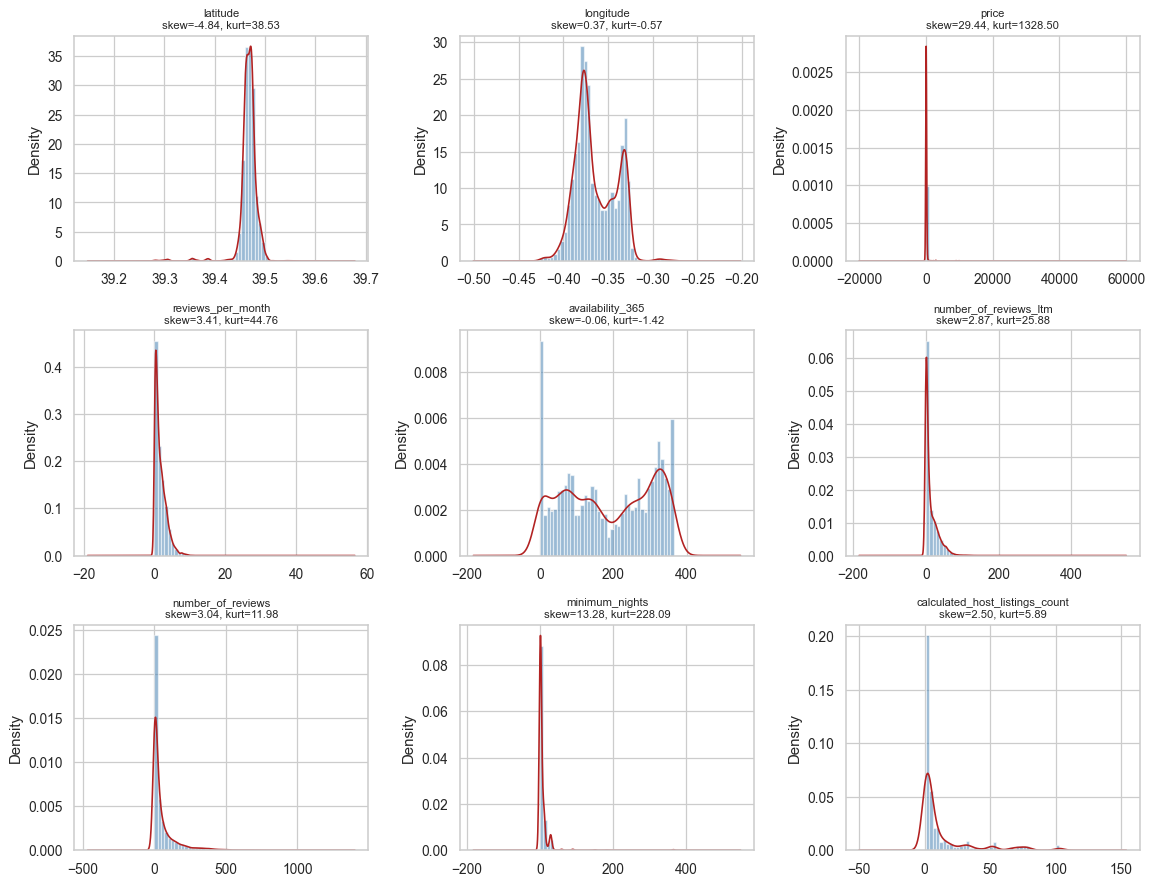

In [47]:
# Histograma + densidade para as variáveis quantitativas mais relevantes
todas_quant = quantitativa_continuas + quantitativa_discretas

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, col in zip(axes.flatten(), todas_quant):
    ser = df[col].dropna()
    ax.hist(ser, bins=40, density=True, alpha=0.55, color="steelblue", edgecolor="white")
    try:
        ser.plot.density(ax=ax, color="firebrick", linewidth=1.3)
    except Exception:
        pass
    ax.set_title(f"{col}\nskew={ser.skew():.2f}, kurt={ser.kurtosis():.2f}", fontsize=9)
    ax.set_xlabel("")
# esconder eixos não usados
for ax in axes.flatten()[len(todas_quant):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig("outputs/fig_histogramas.png", dpi=120, bbox_inches="tight")
plt.show()


## 2.8 Deteção de outliers

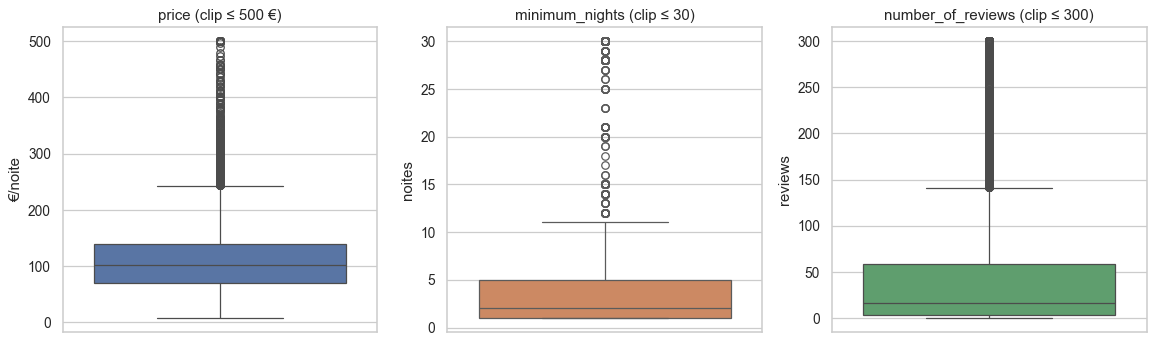

In [48]:
# 3 boxplots lado a lado: price (clip a 500), minimum_nights, number_of_reviews
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

sns.boxplot(y=df["price"].clip(upper=500), ax=axes[0], color="#4C72B0")
axes[0].set_title("price (clip ≤ 500 €)")
axes[0].set_ylabel("€/noite")

sns.boxplot(y=df["minimum_nights"].clip(upper=30), ax=axes[1], color="#DD8452")
axes[1].set_title("minimum_nights (clip ≤ 30)")
axes[1].set_ylabel("noites")

sns.boxplot(y=df["number_of_reviews"].clip(upper=300), ax=axes[2], color="#55A868")
axes[2].set_title("number_of_reviews (clip ≤ 300)")
axes[2].set_ylabel("reviews")

plt.tight_layout()
plt.savefig("outputs/fig_boxplots.png", dpi=120, bbox_inches="tight")
plt.show()


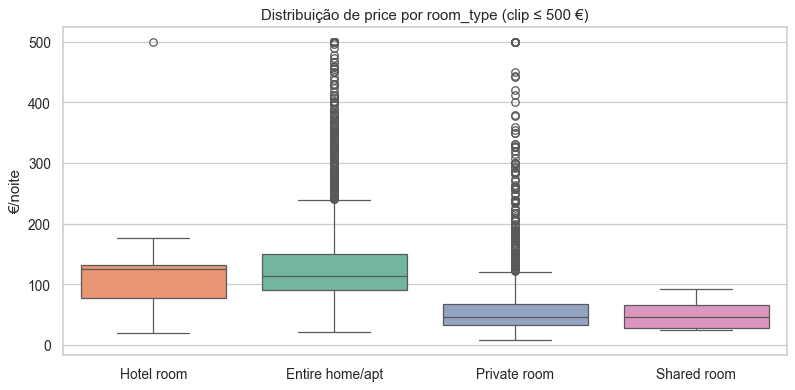

In [49]:
# Boxplot de price por room_type (clip a 500 para leitura)
fig, ax = plt.subplots(figsize=(9, 4.5))
order = df.groupby("room_type", observed=True)["price"].median().sort_values(ascending=False).index
sns.boxplot(
    x="room_type", y=df["price"].clip(upper=500),
    data=df, order=order, ax=ax, palette="Set2", hue="room_type", legend=False
)
ax.set_title("Distribuição de price por room_type (clip ≤ 500 €)")
ax.set_ylabel("€/noite")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("outputs/fig_price_por_roomtype.png", dpi=120, bbox_inches="tight")
plt.show()


## 2.9 Estatísticas de preço por grupos

In [50]:
# Preço por tipo de alojamento
price_por_tipo = (
    df.groupby("room_type", observed=True)["price"]
      .agg(["count", "median", "mean", "std"])
      .round(1)
      .sort_values("median", ascending=False)
)
print("=== Preço por room_type ===")
print(price_por_tipo)


=== Preço por room_type ===
                 count  median   mean    std
room_type                                   
Hotel room          13   125.0  160.2  204.8
Entire home/apt   5236   114.0  196.1  842.0
Private room      1720    46.0   67.3   83.0
Shared room         10    45.5   50.4   24.9


=== Top 10 distritos por volume ===
                     n_listings  mediana_price
neighbourhood_group                           
POBLATS MARITIMS           1471          105.0
CIUTAT VELLA               1284          118.0
QUATRE CARRERES             814          100.0
CAMINS AL GRAU              729           97.5
L'EIXAMPLE                  686          120.0
EXTRAMURS                   637          108.0
ALGIROS                     341           78.0
LA SAIDIA                   329           97.0
JESUS                       282           77.0
L'OLIVERETA                 233           80.0


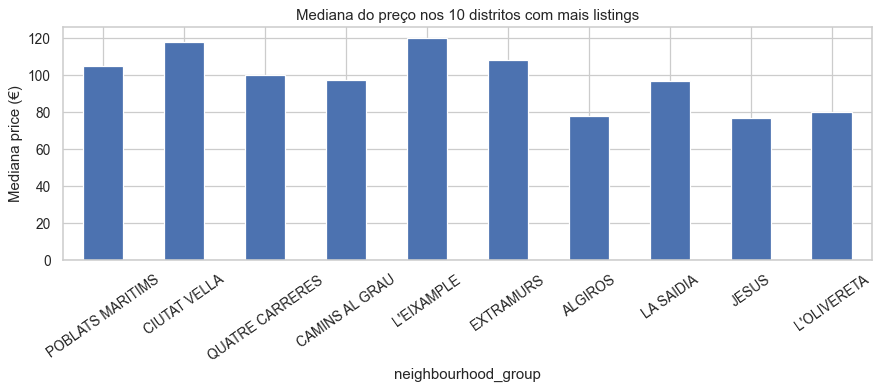

In [51]:
# Top 10 distritos (neighbourhood_group) por número de listings
top_distritos = (
    df.groupby("neighbourhood_group", observed=True)
      .agg(n_listings=("price", "size"),
           mediana_price=("price", "median"))
      .sort_values("n_listings", ascending=False)
      .head(10)
)
print("=== Top 10 distritos por volume ===")
print(top_distritos)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 4.5))
top_distritos["mediana_price"].plot.bar(ax=ax, color="#4C72B0", edgecolor="white")
ax.set_ylabel("Mediana price (€)")
ax.set_title("Mediana do preço nos 10 distritos com mais listings")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.savefig("outputs/fig_top_distritos.png", dpi=120, bbox_inches="tight")
plt.show()


## 2.10 Correlações — Pearson, Spearman, Kendall

In [52]:
# Subconjunto numérico relevante (sem id/host_id)
cols_corr = [
    "price", "reviews_per_month", "number_of_reviews_ltm", "number_of_reviews",
    "minimum_nights", "calculated_host_listings_count",
    "availability_365", "latitude", "longitude"
]

pearson  = df[cols_corr].dropna().corr(method="pearson")
spearman = df[cols_corr].dropna().corr(method="spearman")
kendall  = df[cols_corr].dropna().corr(method="kendall")


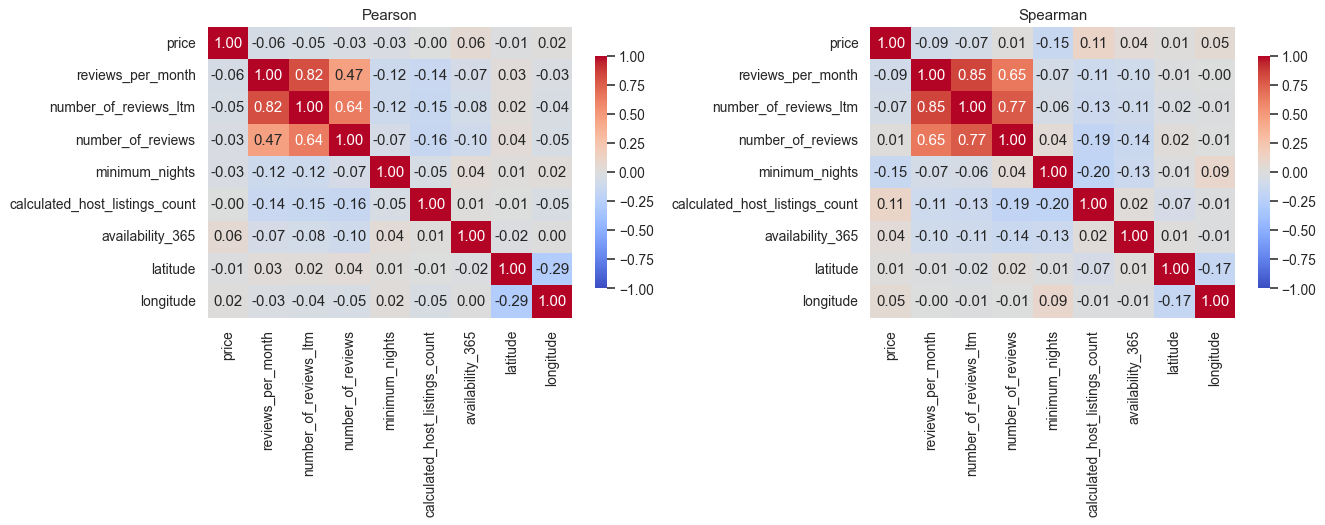

In [53]:
# Heatmap de Pearson
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(pearson, annot=True, fmt=".2f", vmin=-1, vmax=1,
            cmap="coolwarm", center=0, ax=axes[0],
            cbar_kws={"shrink": 0.8})
axes[0].set_title("Pearson")
sns.heatmap(spearman, annot=True, fmt=".2f", vmin=-1, vmax=1,
            cmap="coolwarm", center=0, ax=axes[1],
            cbar_kws={"shrink": 0.8})
axes[1].set_title("Spearman")
plt.tight_layout()
plt.savefig("outputs/fig_heatmap_corr.png", dpi=120, bbox_inches="tight")
plt.show()


In [54]:
# Tabela Pearson vs Spearman vs Kendall — foco em price
tabela_corr = pd.DataFrame({
    "Pearson":  pearson.loc["price"].drop("price").round(4),
    "Spearman": spearman.loc["price"].drop("price").round(4),
    "Kendall":  kendall.loc["price"].drop("price").round(4),
}).sort_values("Spearman", key=abs, ascending=False)
print("=== Correlações de price com cada variável (ordenado por |Spearman|) ===")
print(tabela_corr)


=== Correlações de price com cada variável (ordenado por |Spearman|) ===
                                Pearson  Spearman  Kendall
minimum_nights                  -0.0330   -0.1519  -0.1120
calculated_host_listings_count  -0.0035    0.1111   0.0774
reviews_per_month               -0.0567   -0.0933  -0.0642
number_of_reviews_ltm           -0.0501   -0.0706  -0.0491
longitude                        0.0151    0.0477   0.0325
availability_365                 0.0609    0.0378   0.0251
number_of_reviews               -0.0321    0.0126   0.0085
latitude                        -0.0125    0.0093   0.0069


**Discussão:** Todas as correlações lineares de `price` com as outras variáveis são **muito fracas** (|r| < 0.1 em Pearson). A Spearman revela um sinal mais forte para `minimum_nights` (ρ ≈ −0.18). Isto confirma a limitação do dataset resumido: as variáveis disponíveis **não são as que verdadeiramente explicam o preço** — o que mais explica (quartos, casas-de-banho, capacidade, amenities) está ausente.

## 2.11 Scatter plots — preditores numéricos vs price 

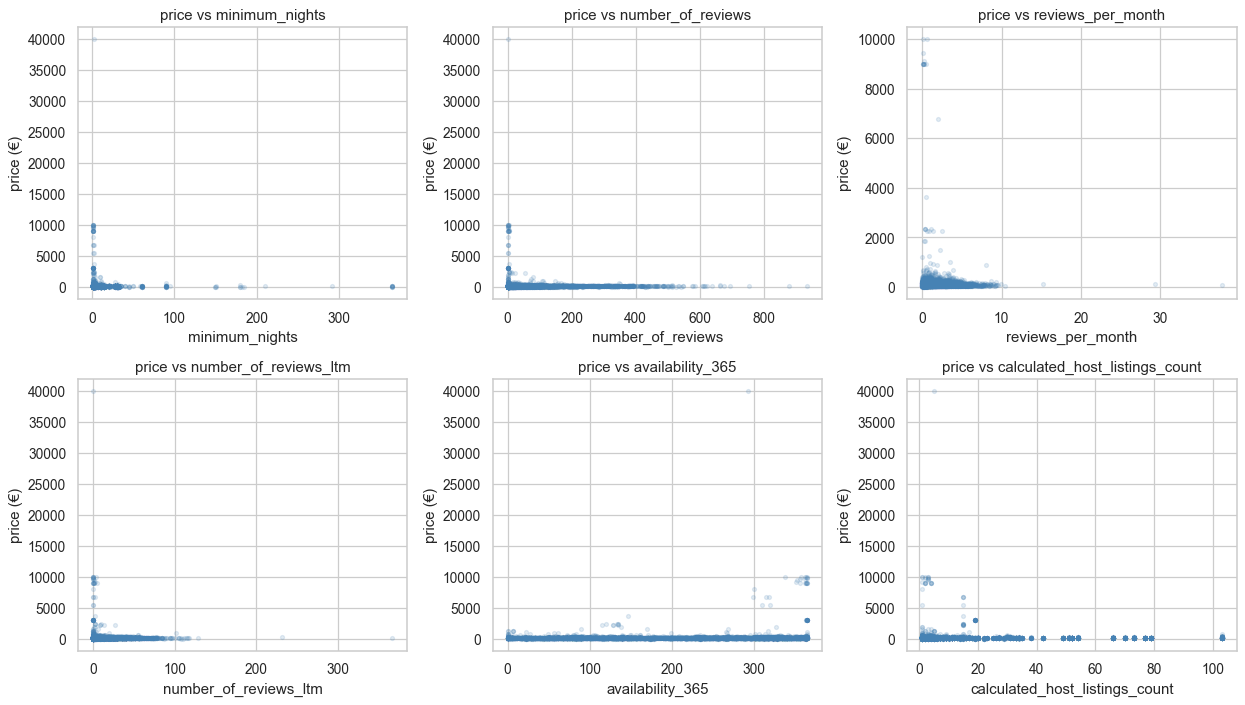

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

num_vars = [
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "number_of_reviews_ltm",
    "availability_365",
    "calculated_host_listings_count",
    
]

for ax, col in zip(axes.flatten(), num_vars):
    sub = df[[col, "price"]].dropna()

    ax.scatter(
        sub[col],
        sub["price"],
        alpha=0.15,
        s=10,
        color="steelblue"
    )

    ax.set_xlabel(col)
    ax.set_ylabel("price (€)")
    ax.set_title(f"price vs {col}")

plt.tight_layout()
plt.savefig("outputs/fig_scatter_price_linear.png", dpi=120, bbox_inches="tight")
plt.show()

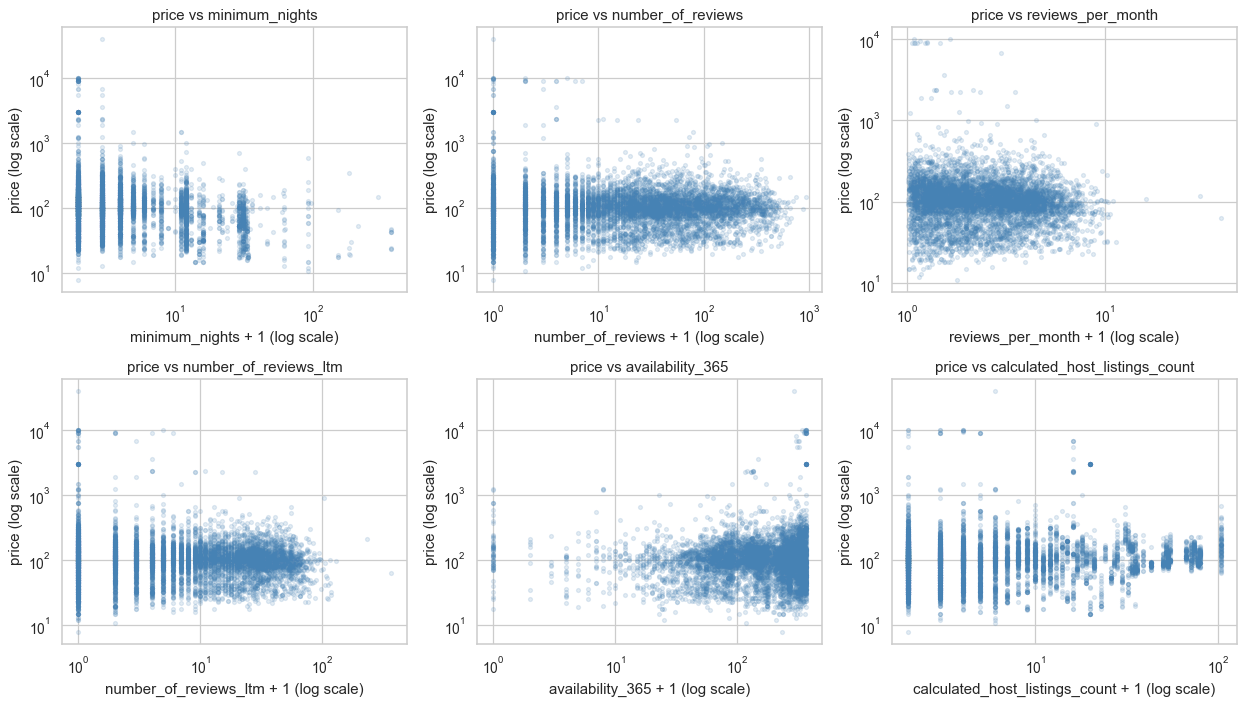

In [56]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))


for ax, col in zip(axes.flatten(), num_vars):
    sub = df[[col, "price"]].dropna()
    sub = sub[sub["price"] > 0].copy()

    x = sub[col] + 1  # para evitar problemas com zeros

    ax.scatter(x, sub["price"], alpha=0.15, s=10, color="steelblue")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(f"{col} + 1 (log scale)")
    ax.set_ylabel("price (log scale)")
    ax.set_title(f"price vs {col}")

plt.tight_layout()
plt.savefig("outputs/fig_scatter_price.png", dpi=120, bbox_inches="tight")
plt.show()


## 2.12 Gráficos geoespaciais

Dois mapas: (a) hexbin do preço mediano por localização, que funciona sempre (offline); (b) mapa com basemap `contextily` por cima das coordenadas — dentro de try/except para que o notebook não falhe sem internet.

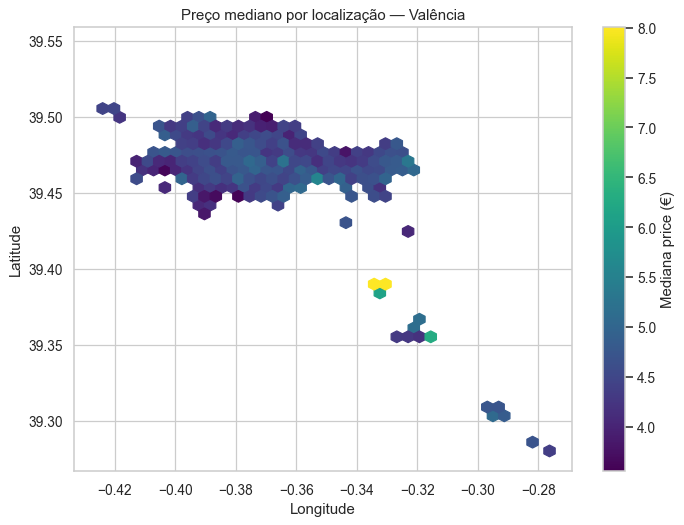

In [ ]:
# Hexbin preço médio por localização (offline — sempre corre)
fig, ax = plt.subplots(figsize=(8, 6))
hb = ax.hexbin(df["longitude"], df["latitude"], C=np.log(df["price"]),
               reduce_C_function=np.median, gridsize=40, cmap="viridis", mincnt=3)
cb = fig.colorbar(hb, ax=ax, label="média price (€)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Preço mediano por localização — Valência")
plt.tight_layout()
plt.savefig("outputs/fig_hexbin_price.png", dpi=120, bbox_inches="tight")
plt.show()


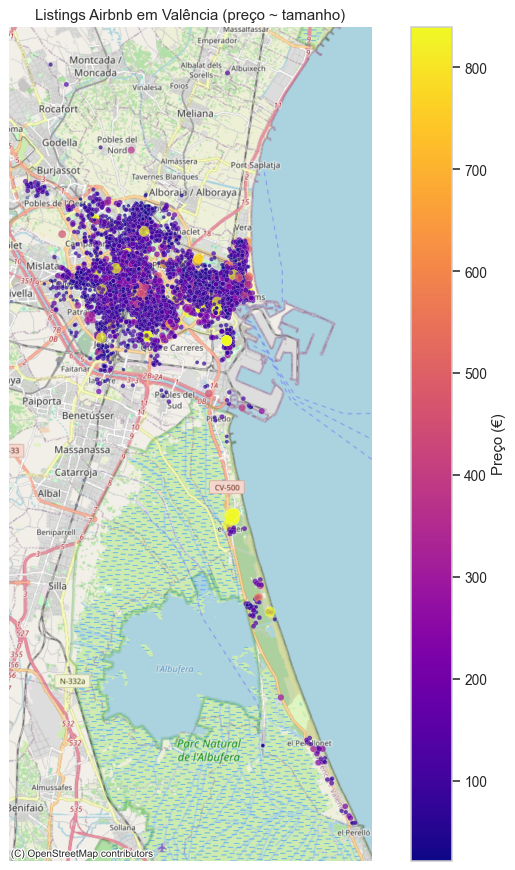

✓ Mapa com basemap gerado com sucesso.


In [58]:
# Mapa com basemap contextily — opcional, protegido por try/except
# (precisa de internet para descarregar os tiles; se falhar, o notebook continua)
try:
    import geopandas as gpd
    import contextily as ctx

    geometry = gpd.points_from_xy(df["longitude"], df["latitude"])
    gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326").to_crs(epsg=3857)

    # Reduzir efeito de outliers no preço para o mapa
    price_clip = gdf["price"].clip(
        lower=gdf["price"].quantile(0.01),
        upper=gdf["price"].quantile(0.99)
    )
    sizes = np.interp(price_clip, (price_clip.min(), price_clip.max()), (8, 70))

    fig, ax = plt.subplots(figsize=(9, 10))
    gdf.plot(ax=ax, column=price_clip, cmap="plasma", markersize=sizes,
             alpha=0.7, legend=True, legend_kwds={"label": "Preço (€)"},
             edgecolor="white", linewidth=0.15)

    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
    ax.set_title("Listings Airbnb em Valência (preço ~ tamanho)")
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig("outputs/fig_mapa_basemap.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("✓ Mapa com basemap gerado com sucesso.")
except Exception as e:
    print(f"⚠ Mapa com basemap saltado (provavelmente sem internet): {type(e).__name__}: {e}")
    print("  O notebook continua normalmente — este gráfico é opcional.")


## 2.13 Missing values

- **price (865, 11%)**: alvo do modelo; estas linhas têm de ser removidas.
- **last_review e reviews_per_month (977 cada)**: coincidem — são listings sem qualquer review (alojamentos novos ou inactivos).
- **license (3311, 42%)**: muitos listings não têm número de licença visível. Transformamos em feature binária `license_exists` em vez de descartar.
- **host_name (6, 0.08%)**: insignificante.

A mediana de `price` para listings com e sem review é **102 €** vs **95 €** — listings novos sem reviews tendem a pedir um pouco menos.

In [59]:
def missing_detection(df, export=False, export_name="missing_report.xlsx"):
    na = df.isnull().sum()
    na = na[na > 0].sort_values(ascending=False)
    out = pd.DataFrame({
        "# NAs": na,
        "% NAs": (na / len(df) * 100).round(2)
    })
    obs = df.isnull().sum(axis=1)
    obs_with_na = (obs > 0).sum()

    out.loc["Total de observações com >1 valor omitido"] = {
        "# NAs": obs_with_na,
        "% NAs": round((obs_with_na / len(df)) * 100, 2)
    }
    if export:
        out.to_excel(f"{CAMINHO_OUTPUTS}/{export_name}", index=True)
    return out

print("=== Missings no dataset original ===")
print(missing_detection(df))


=== Missings no dataset original ===
                                           # NAs  % NAs
license                                     3311  42.21
reviews_per_month                            977  12.46
last_review                                  977  12.46
price                                        865  11.03
host_name                                      6   0.08
Total de observações com >1 valor omitido   3940  50.23


In [60]:
# Mediana de price segmentada por existência de reviews
print(f"Mediana global:           {df['price'].median()}")
print(f"Com last_review:          {df['price'].loc[df['last_review'].notnull()].median()}")
print(f"Sem last_review:          {df['price'].loc[df['last_review'].isnull()].median()}")


Mediana global:           102.0
Com last_review:          102.0
Sem last_review:          95.0


#### Análise da variável licença

In [61]:
with_license = df.loc[df["license"].notna() & df["license"].notnull(), "price"].describe()
with_license["median"] = df.loc[df["license"].notna() & df["license"].notnull(), "price"].median()
display(with_license)
no_license = df.loc[df["license"].isna() | df["license"].isnull(), "price"].describe()
no_license["median"] = df.loc[df["license"].isna() | df["license"].isnull(), "price"].median()
display(no_license)

count      4165.000000
mean        196.351501
std         925.019135
min          16.000000
25%          90.000000
50%         112.000000
75%         147.000000
max       40000.000000
median      112.000000
Name: price, dtype: float64

count     2814.000000
mean       116.397655
std        247.136007
min          8.000000
25%         44.000000
50%         75.000000
75%        123.000000
max       3000.000000
median      75.000000
Name: price, dtype: float64

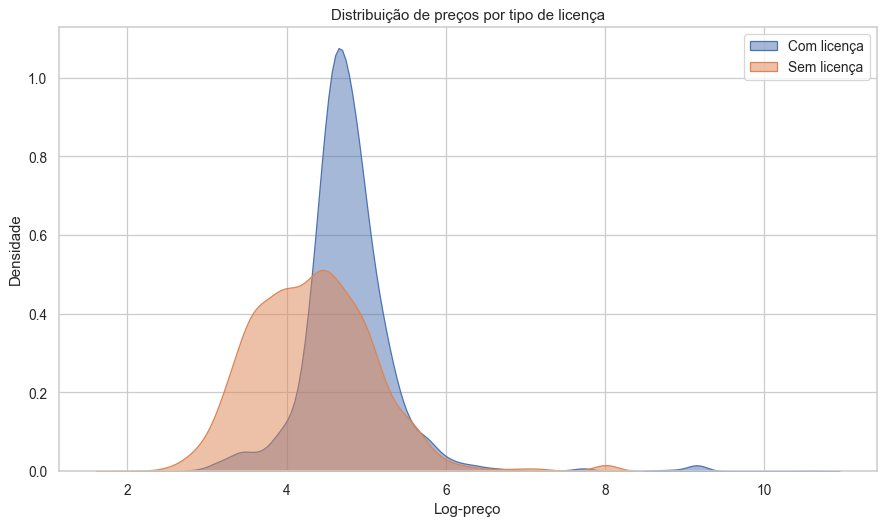

In [62]:
# distribuição de preços para anúncios com e sem licença
plt.figure(figsize=(10, 6))
sns.kdeplot(np.log(df.loc[df["license"].notna() & df["license"].notnull(), "price"]), label="Com licença", fill=True, alpha=0.5)
sns.kdeplot(np.log(df.loc[df["license"].isna() | df["license"].isnull(), "price"]), label="Sem licença", fill=True, alpha=0.5)
plt.xlabel("Log-preço")
plt.ylabel("Densidade")
plt.title("Distribuição de preços por tipo de licença")
plt.legend()
plt.tight_layout()
plt.show()

---
# 3. Data Preparation

Pipeline de limpeza e feature engineering. **Ordem correcta** (o original tinha a detecção de outliers antes de criar as features que ela usava):

1. Remover NAs do alvo (`price`).
2. Tratar NAs residuais (`reviews_per_month`, `last_review`, `license`, `host_name`).
3. Criar todas as features derivadas.
4. K-Means sobre latitude/longitude (criar clusters).
5. Gerar dummies.
6. Detectar outliers (multi-método) e remover os extremos.
7. Selecção final de variáveis com VIF.


## 3.1 Limpeza de NAs

In [63]:
# 1. Remover linhas sem price
n0 = len(df)
df = df.dropna(subset=["price"]).copy()
print(f"Removidas {n0 - len(df)} linhas sem price. Restam: {len(df)}")

# 2. reviews_per_month: NA = 0 reviews (listing novo) → preencher com 0
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

# 3. host_name: substituir por "Unknown"
df["host_name"] = df["host_name"].astype("object").fillna("Unknown").astype("category")

# 4. last_review: manter NA (vai virar days_since_last_review)
print("\nNAs após limpeza:")
print(missing_detection(df))


Removidas 865 linhas sem price. Restam: 6979

NAs após limpeza:
                                           # NAs  % NAs
license                                     2814  40.32
last_review                                  819  11.74
Total de observações com >1 valor omitido   3069  43.97


## 3.2 Feature engineering

In [64]:
# log-transformações (price e minimum_nights têm cauda pesada)
df["log_price"] = np.log(df["price"])
df["log_minimum_nights"] = np.log(df["minimum_nights"] + 1)

# Taxa de disponibilidade (0 a 1)
df["availability_rate"] = df["availability_365"] / 365.0

# Intensidade de reviews: reviews totais * reviews por mês
df["review_intensity"] = df["number_of_reviews"] * df["reviews_per_month"]

# Dias desde o último review — para listings sem review, usar valor máximo + 1
data_ref = df["last_review"].max()
df["days_since_last_review"] = (data_ref - df["last_review"]).dt.days
max_days = df["days_since_last_review"].max()
df["days_since_last_review"] = df["days_since_last_review"].fillna(max_days + 30)

# license_exists: 1 se existe licença visível
df["license_exists"] = df["license"].notna().astype(int)

# has_reviews: 1 se tem pelo menos um review
df["has_reviews"] = (df["number_of_reviews"] > 0).astype(int)

# profissional: 1 se o anfitrião gere >= 10 listings (gestor profissional vs particular)
df["profissional"] = (df["calculated_host_listings_count"] >= 10).astype(int)

print("Features criadas:", ["log_price", "log_minimum_nights", "availability_rate",
                            "review_intensity", "days_since_last_review",
                            "license_exists", "has_reviews", "profissional"])
df[["log_price", "log_minimum_nights", "availability_rate",
    "days_since_last_review", "license_exists", "has_reviews", "profissional"]].head()


Features criadas: ['log_price', 'log_minimum_nights', 'availability_rate', 'review_intensity', 'days_since_last_review', 'license_exists', 'has_reviews', 'profissional']


,log_price,log_minimum_nights,availability_rate,days_since_last_review,license_exists,has_reviews,profissional
0,4.418841,1.386294,0.410959,8.0,1,1,0
1,5.966147,2.397895,0.054795,4466.0,1,1,0
2,5.501258,1.098612,0.786301,8.0,1,1,0
3,4.820282,1.791759,0.290411,20.0,1,1,0
4,4.919981,1.386294,0.482192,190.0,1,1,0


### 3.2.1 Clustering geográfico K-Means

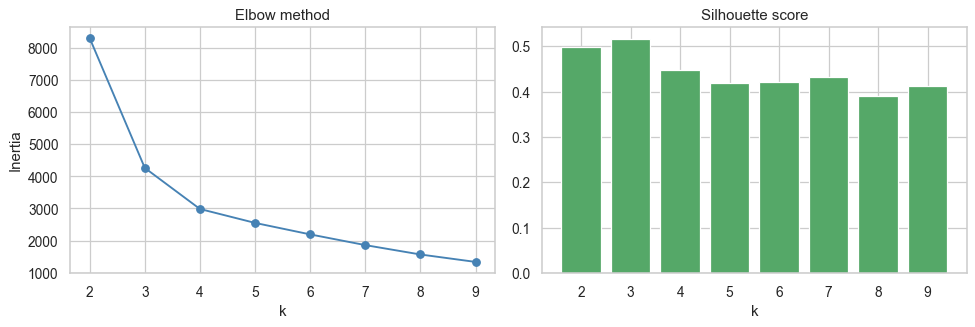


Silhouette por k: {2: np.float64(0.4986), 3: np.float64(0.5166), 4: np.float64(0.4478), 5: np.float64(0.4182), 6: np.float64(0.4211), 7: np.float64(0.4326), 8: np.float64(0.3901), 9: np.float64(0.412)}


In [65]:

# Escalonamento das coordenadas
X_geo = df[["latitude", "longitude"]].astype(float).values
X_geo_scaled = StandardScaler().fit_transform(X_geo)

# Elbow method
inertia = []
k_range = range(2, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_geo_scaled)
    inertia.append(km.inertia_)

# Silhouette
sil_scores = {}
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_geo_scaled)
    sil_scores[k] = silhouette_score(X_geo_scaled, labels)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(list(k_range), inertia, marker="o", color="steelblue")
axes[0].set_title("Elbow method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].bar(list(sil_scores.keys()), list(sil_scores.values()), color="#55A868")
axes[1].set_title("Silhouette score"); axes[1].set_xlabel("k")
plt.tight_layout(); plt.savefig("outputs/fig_kmeans_elbow.png", dpi=120); plt.show()

print("\nSilhouette por k:", {k: round(v, 4) for k, v in sil_scores.items()})


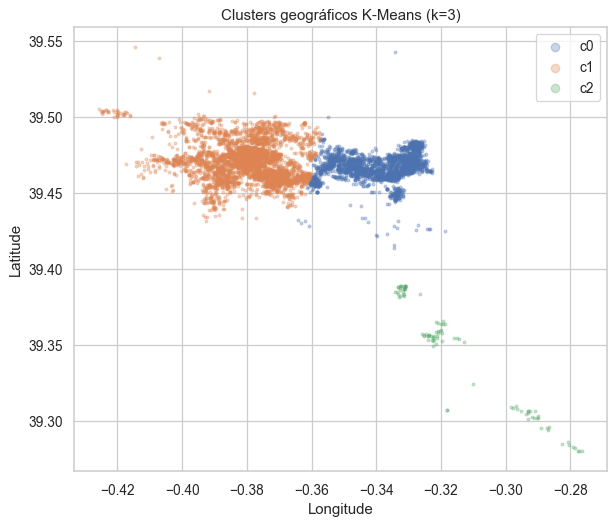

,count,median,mean
location_cluster,,,
c0,2558,101.0,184.6
c1,4325,102.0,139.1
c2,96,135.5,744.4


In [66]:
# Clustering final com k=3
K_OPT = 3
kmeans = KMeans(n_clusters=K_OPT, random_state=RANDOM_STATE, n_init=10)
df["location_cluster"] = kmeans.fit_predict(X_geo_scaled).astype(str)
df["location_cluster"] = "c" + df["location_cluster"]

# Visualizar clusters
fig, ax = plt.subplots(figsize=(7, 6))
for c, color in zip(sorted(df["location_cluster"].unique()), ["#4C72B0", "#DD8452", "#55A868"]):
    sub = df[df["location_cluster"] == c]
    ax.scatter(sub["longitude"], sub["latitude"], s=5, alpha=0.3, color=color, label=c)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"Clusters geográficos K-Means (k={K_OPT})")
ax.legend(markerscale=3)
plt.tight_layout(); plt.savefig("outputs/fig_clusters.png", dpi=120); plt.show()

df.groupby("location_cluster", observed=True)["price"].agg(["count", "median", "mean"]).round(1)


In [67]:
df["location_cluster"] = np.select(
    [
        df["location_cluster_c1"] == 1,
        df["location_cluster_c2"] == 1
    ],
    [
        "c1",
        "c2"
    ],
    default="c0"
)

KeyError: 'location_cluster_c1'

In [ ]:

ct = pd.crosstab(df["location_cluster"], df["neighbourhood"])
ct_prop = ct.div(ct.sum(axis=1), axis=0)

for c in ct_prop.index:
    print(f"\n{c}")
    print(ct_prop.loc[c].sort_values(ascending=False).head(5))

KeyError: 'location_cluster_c1'

In [ ]:
df.groupby("location_cluster")["price"].mean()

location_cluster
c0    123.345262
c1    117.521094
c2    653.000000
Name: price, dtype: float64

In [ ]:
df.groupby("location_cluster").agg({
    "price": ["mean", "std"],
    "availability_rate": "mean",
    "review_intensity": "mean"
})

price              availability_rate review_intensity
                        mean          std              mean             mean
location_cluster                                                            
c0                123.345262   156.160500          0.543223       122.478262
c1                117.521094    94.236683          0.541104       186.200941
c2                653.000000  1107.687979          0.723230        30.342526

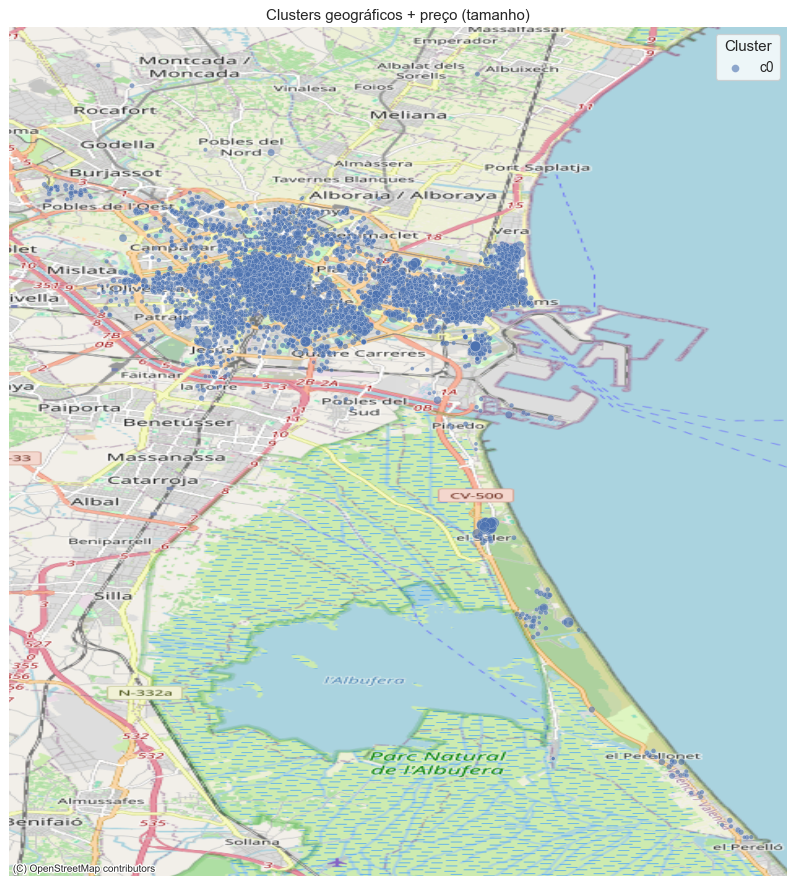

In [ ]:
try:
    import geopandas as gpd
    import contextily as ctx
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    # garantir que só entram linhas válidas para o mapa
    df_map = df.dropna(subset=["longitude", "latitude", "price", "location_cluster"]).copy()

    geometry = gpd.points_from_xy(df_map["longitude"], df_map["latitude"])
    gdf = gpd.GeoDataFrame(df_map, geometry=geometry, crs="EPSG:4326").to_crs(epsg=3857)

    # clipping do preço
    price_clip = gdf["price"].clip(
        lower=gdf["price"].quantile(0.01),
        upper=gdf["price"].quantile(0.99)
    )

    # tamanhos com o mesmo índice do gdf
    sizes = pd.Series(
        np.interp(price_clip, (price_clip.min(), price_clip.max()), (8, 70)),
        index=gdf.index
    )

    colors = {
        "c0": "#4C72B0",
        "c1": "#DD8452",
        "c2": "#55A868"
    }

    fig, ax = plt.subplots(figsize=(9, 10))

    for c in sorted(gdf["location_cluster"].unique()):
        sub = gdf[gdf["location_cluster"] == c]
        ax.scatter(
            sub.geometry.x,
            sub.geometry.y,
            s=sizes.loc[sub.index],
            color=colors.get(c, "gray"),
            alpha=0.6,
            label=c,
            edgecolor="white",
            linewidth=0.2
        )

    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
    ax.set_title("Clusters geográficos + preço (tamanho)")
    ax.set_axis_off()
    ax.legend(title="Cluster")

    plt.tight_layout()
    plt.savefig("outputs/fig_clusters_basemap.png", dpi=120, bbox_inches="tight")
    plt.show()

except Exception as e:
    print(f"Erro no mapa: {e}")

### 3.2.2 Dummies para variáveis categóricas

In [ ]:
# Guardar o room_type ORIGINAL antes do get_dummies — vamos usá-lo mais à frente
# para estratificar o split treino/teste (garante que as 4 categorias de room_type
# ficam representadas proporcionalmente em ambos os conjuntos).
# NOTA: o nome NÃO pode começar por "room_type_" porque mais à frente
# selecionamos as dummies com startswith("room_type_") e colidiria.
df["strat_roomtype"] = df["room_type"].astype(str)

# Criar dummies com drop_first (evita dummy trap)
df = pd.get_dummies(df, columns=["room_type", "location_cluster"], drop_first=True, dtype=int)

# Colunas dummy criadas
dummy_cols = [c for c in df.columns if c.startswith("room_type_") or c.startswith("location_cluster_")]
print("Dummies criadas:", dummy_cols)
print("strat_roomtype preservada para o stratify do split:", df["strat_roomtype"].value_counts().to_dict())


Dummies criadas: ['room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'location_cluster_c1', 'location_cluster_c2']
strat_roomtype preservada para o stratify do split: {'Entire home/apt': 5236, 'Private room': 1720, 'Hotel room': 13, 'Shared room': 10}


## 3.5 Detecção de outliers (multi-método) e remoção de extremos

Função do colega (MAD, IQR, percentis, Mahalanobis, Isolation Forest, LOF) — mantida mas corrigida: só chamada **depois** de criar as features.

In [ ]:
def detect_outliers_all(df, univariate_cols, multivariate_cols):
    """Flags de outliers por múltiplos métodos, com score final.
    Mantida do trabalho original, chamada na ordem correcta."""
    results = pd.DataFrame(index=df.index)

    # ---- 1. Univariado ----
    for col in univariate_cols:
        s = pd.to_numeric(df[col], errors="coerce")
        median = np.median(s.dropna())
        mad = np.median(np.abs(s.dropna() - median))
        if mad != 0:
            modified_z = 0.6745 * (s - median) / mad
            results[f"{col}_mad"] = np.abs(modified_z) > 3.5
        else:
            results[f"{col}_mad"] = False
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        results[f"{col}_iqr"] = (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)
        low, high = s.quantile(0.01), s.quantile(0.99)
        results[f"{col}_perc"] = (s < low) | (s > high)

    # ---- 2. Multivariado ----
    X = df[multivariate_cols].apply(pd.to_numeric, errors="coerce").dropna()
    if not X.empty:
        mean = X.mean().values
        cov = np.cov(X, rowvar=False) + np.eye(len(multivariate_cols)) * 1e-8
        inv_cov = np.linalg.inv(cov)
        dist = X.apply(lambda r: mahalanobis(r.values, mean, inv_cov), axis=1) ** 2
        cutoff = chi2.ppf(0.99, df=len(multivariate_cols))
        results["mahalanobis"] = False
        results.loc[X.index, "mahalanobis"] = dist > cutoff

        iso = IsolationForest(contamination=0.01, random_state=RANDOM_STATE)
        results["isolation_forest"] = False
        results.loc[X.index, "isolation_forest"] = iso.fit_predict(X) == -1

        lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
        results["lof"] = False
        results.loc[X.index, "lof"] = lof.fit_predict(X) == -1

    # ---- 3. Score (nº de métodos que flagged a linha) ----
    results["outlier_score"] = results.sum(axis=1)
    results["is_outlier"] = results["outlier_score"] >= 3  # pelo menos 3 métodos

    return results


cols_out = [
    "log_price", "log_minimum_nights",
    "availability_rate", "review_intensity",
    "days_since_last_review", "calculated_host_listings_count",
]
out_flags = detect_outliers_all(df, cols_out, cols_out)

print("=== Flags por método ===")
print(out_flags.iloc[:, :-2].sum())
print(f"\nLinhas flagged por >= 3 métodos: {out_flags['is_outlier'].sum()}")


=== Flags por método ===
log_price_mad                           113
log_price_iqr                           329
log_price_perc                          139
log_minimum_nights_mad                  451
log_minimum_nights_iqr                  503
log_minimum_nights_perc                  70
availability_rate_mad                     0
availability_rate_iqr                     0
availability_rate_perc                   69
review_intensity_mad                   1880
review_intensity_iqr                    957
review_intensity_perc                    70
days_since_last_review_mad             1731
days_since_last_review_iqr             1314
days_since_last_review_perc               0
calculated_host_listings_count_mad     1553
calculated_host_listings_count_iqr     1070
calculated_host_listings_count_perc       0
mahalanobis                             306
isolation_forest                         69
lof                                      70
dtype: int64

Linhas flagged por >= 3 métodos: 1159

In [ ]:
# Remoção de outliers EXTREMOS (não todos os flagged — apenas os claramente errados)
# Critério: preço impossível (> 10 000 €/noite) ou flagged por >=3 métodos E price > 3000
n_antes = len(df)
extremos = (df["price"] > 10000) | (out_flags["is_outlier"] & (df["price"] > 3000))
df = df[~extremos].copy()
print(f"Removidas {n_antes - len(df)} linhas (outliers extremos de preço).")
print(f"Dataset final: {len(df)} linhas")

# Recalcular log_price após remoção (apenas actualiza índice, valores inalterados)
print(f"price: min={df['price'].min()}, max={df['price'].max()}, mediana={df['price'].median()}")


Removidas 27 linhas (outliers extremos de preço).
Dataset final: 6952 linhas
price: min=8.0, max=3000.0, mediana=102.0


## 3.6 Selecção final de variáveis e VIF

In [ ]:
# Conjunto de preditores para os modelos.
# Nota: `days_since_last_review` foi INICIALMENTE considerada mas foi descartada após
# um primeiro cálculo de VIF — tem colinearidade quase perfeita com `has_reviews`
# (listings sem reviews ficam todos com o mesmo valor máximo de dias, por construção),
# produzindo VIF ≈ 32. Mantemos `has_reviews` como indicador binário mais parcimonioso.
preditores = [
    "log_minimum_nights",
    "availability_rate",
    "calculated_host_listings_count",
    "number_of_reviews_ltm",
    "license_exists",
    "has_reviews",
    "profissional",
] + [c for c in df.columns if c.startswith("room_type_") or c.startswith("location_cluster_")]

print(f"Preditores seleccionados ({len(preditores)}):")
for p in preditores:
    print(f"  • {p}")

# Construir X e y — y é AGORA o array real, não uma string
X_full = df[preditores].astype(float).copy()
y_full = df["log_price"].astype(float).copy()

# Alinhar: sem NAs
mask = X_full.notna().all(axis=1) & y_full.notna()
X_full = X_full.loc[mask]
y_full = y_full.loc[mask]
print(f"\nShape X_full: {X_full.shape},  y_full: {y_full.shape}")


Preditores seleccionados (12):
  • log_minimum_nights
  • availability_rate
  • calculated_host_listings_count
  • number_of_reviews_ltm
  • license_exists
  • has_reviews
  • profissional
  • room_type_Hotel room
  • room_type_Private room
  • room_type_Shared room
  • location_cluster_c1
  • location_cluster_c2

Shape X_full: (6952, 12),  y_full: (6952,)


**Interpretação VIF:** O termo `const` tem VIF alto por construção (não é preocupante). Todas as outras variáveis devem estar abaixo de 5, o que indica baixa multicolinearidade entre os preditores seleccionados.

---
# 4. Modelação

Implementação dos 5 modelos exigidos pelo enunciado, com train/test split fixo (`random_state=42`) para permitir comparação directa.


## 4.1 Train/test split estratificado

`room_type` é fortemente desbalanceado (~74 % Entire home/apt, <1 % Hotel/Shared room). Usamos **split estratificado** por `room_type` para garantir que todas as categorias ficam representadas no teste — sem isto, existe risco de as categorias raras cairem todas no treino e o teste ficar enviesado.

In [ ]:
# Stratify por room_type original (que guardámos antes do get_dummies)
strat = df.loc[X_full.index, "strat_roomtype"]

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=RANDOM_STATE, stratify=strat
)
print(f"Treino: {X_train.shape[0]} linhas, Teste: {X_test.shape[0]} linhas")
print()
print("Distribuição de room_type:")
strat_train = df.loc[X_train.index, "strat_roomtype"].value_counts(normalize=True).round(4)
strat_test  = df.loc[X_test.index,  "strat_roomtype"].value_counts(normalize=True).round(4)
print(pd.DataFrame({"treino (%)": strat_train * 100, "teste (%)": strat_test * 100}))

# Baseline (modelo trivial: prever sempre a média)
baseline_pred = np.full_like(y_test.values, fill_value=y_train.mean())
baseline_r2   = r2_score(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mae  = mean_absolute_error(y_test, baseline_pred)
print(f"\nBaseline (prever média): R²={baseline_r2:.4f}, RMSE={baseline_rmse:.4f}, MAE={baseline_mae:.4f}")

# Lista para ir guardando resultados
resultados = []
resultados.append(("Baseline (média)", baseline_r2, baseline_rmse, baseline_mae, 0))


Treino: 5561 linhas, Teste: 1391 linhas

Distribuição de room_type:
                 treino (%)  teste (%)
strat_roomtype                        
Entire home/apt       74.93      74.91
Private room          24.74      24.73
Hotel room             0.18       0.22
Shared room            0.14       0.14

Baseline (prever média): R²=-0.0003, RMSE=0.6400, MAE=0.4673


## 4.2 Modelo 1 — Regressão linear simples (só room_type)

Responde à Q1: **até que ponto só o tipo de alojamento explica o preço?**

In [ ]:
rt_cols = [c for c in X_train.columns if c.startswith("room_type_")]
X_tr1 = X_train[rt_cols]
X_te1 = X_test[rt_cols]

m1 = LinearRegression().fit(X_tr1, y_train)
pred1 = m1.predict(X_te1)

r2_1   = r2_score(y_test, pred1)
rmse_1 = np.sqrt(mean_squared_error(y_test, pred1))
mae_1  = mean_absolute_error(y_test, pred1)

print(f"Modelo 1 — Só room_type")
print(f"  R²   = {r2_1:.4f}")
print(f"  RMSE = {rmse_1:.4f}")
print(f"  MAE  = {mae_1:.4f}")
print(f"  Intercept = {m1.intercept_:.4f}")
for col, coef in zip(rt_cols, m1.coef_):
    print(f"  {col}: {coef:+.4f}")

resultados.append(("M1 — Só room_type", r2_1, rmse_1, mae_1, len(rt_cols)))


Modelo 1 — Só room_type
  R²   = 0.2942
  RMSE = 0.5376
  MAE  = 0.3734
  Intercept = 4.7983
  room_type_Hotel room: -0.3571
  room_type_Private room: -0.8848
  room_type_Shared room: -0.8884


In [ ]:
import statsmodels.api as sm
import pandas as pd

def backward_stepwise(X, y, criterion="aic", verbose=True):
    """
    Backward selection com base em AIC ou BIC.

    Parameters
    ----------
    X : pandas.DataFrame
        DataFrame com os preditores.
    y : pandas.Series ou array-like
        Variável dependente.
    criterion : str
        "aic" ou "bic".
    verbose : bool
        Se True, imprime os passos.

    Returns
    -------
    model_final : statsmodels regression results
        Modelo final ajustado.
    selected_vars : list
        Lista final de variáveis mantidas.
    history : list
        Histórico dos passos.
    """
    if criterion not in ["aic", "bic"]:
        raise ValueError("criterion deve ser 'aic' ou 'bic'")

    X = X.copy()
    y = pd.Series(y).copy()

    selected_vars = list(X.columns)
    history = []

    def fit_model(vars_list):
        X_model = sm.add_constant(X[vars_list], has_constant="add")
        return sm.OLS(y, X_model).fit()

    current_model = fit_model(selected_vars)
    current_score = current_model.aic if criterion == "aic" else current_model.bic

    if verbose:
        print(f"Modelo inicial ({criterion.upper()} = {current_score:.3f})")
        print("Variáveis:", selected_vars)
        print()

    while len(selected_vars) > 1:
        scores_with_candidates = []

        for var in selected_vars:
            candidate_vars = [v for v in selected_vars if v != var]
            candidate_model = fit_model(candidate_vars)
            candidate_score = candidate_model.aic if criterion == "aic" else candidate_model.bic
            scores_with_candidates.append((candidate_score, var, candidate_model, candidate_vars))

        scores_with_candidates.sort(key=lambda x: x[0])
        best_new_score, var_to_remove, best_model, best_vars = scores_with_candidates[0]

        if best_new_score < current_score:
            if verbose:
                print(
                    f"Remover '{var_to_remove}' "
                    f"-> {criterion.upper()} {current_score:.3f} -> {best_new_score:.3f}"
                )

            history.append({
                "removed": var_to_remove,
                "old_score": current_score,
                "new_score": best_new_score,
                "remaining_vars": best_vars.copy()
            })

            selected_vars = best_vars
            current_model = best_model
            current_score = best_new_score
        else:
            if verbose:
                print()
                print("Paragem: remover qualquer variável piora o critério.")
            break

    return current_model, selected_vars, history

# Aplicar backward stepwise com AIC
modelo_aic, vars_aic, history_aic = backward_stepwise(X_tr1, y_train, criterion="aic", verbose=True)
# Aplicar backward stepwise com BIC
modelo_bic, vars_bic, history_bic = backward_stepwise(X_tr1, y_train, criterion="bic", verbose=True)
print("\n=== Modelo final AIC ===")
print(modelo_aic.summary())
print("\n=== Modelo final BIC ===")
print(modelo_bic.summary())

Modelo inicial (AIC = 8839.530)
Variáveis: ['room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room']


Paragem: remover qualquer variável piora o critério.
Modelo inicial (BIC = 8866.024)
Variáveis: ['room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room']

Remover 'room_type_Hotel room' -> BIC 8866.024 -> 8861.839

Paragem: remover qualquer variável piora o critério.

=== Modelo final AIC ===
                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.338
Method:                 Least Squares   F-statistic:                     945.6
Date:                Sat, 11 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:54:23   Log-Likelihood:                -4415.8
No. Observations:                5561   AIC:                             8840.
Df Residuals: 

**Interpretação Modelo 1:** Os coeficientes são em log; para converter em variação percentual de preço face a Entire home/apt (categoria base), `exp(coef) - 1`. Por exemplo, coef ≈ −0.5 significa preço ~39% mais baixo.

## 4.3 Modelo 2 — Regressão linear múltipla (todos os preditores)

In [ ]:
m2 = LinearRegression().fit(X_train, y_train)
pred2 = m2.predict(X_test)

r2_2   = r2_score(y_test, pred2)
rmse_2 = np.sqrt(mean_squared_error(y_test, pred2))
mae_2  = mean_absolute_error(y_test, pred2)

print(f"Modelo 2 — Linear múltipla ({X_train.shape[1]} preditores)")
print(f"  R²   = {r2_2:.4f}")
print(f"  RMSE = {rmse_2:.4f}")
print(f"  MAE  = {mae_2:.4f}")

resultados.append(("M2 — Linear múltipla", r2_2, rmse_2, mae_2, X_train.shape[1]))


Modelo 2 — Linear múltipla (12 preditores)
  R²   = 0.3993
  RMSE = 0.4959
  MAE  = 0.3551


In [ ]:
# Tabela de coeficientes com p-values (usando statsmodels OLS)
X_tr_sm = sm.add_constant(X_train)
X_te_sm = sm.add_constant(X_test)
ols_m2 = sm.OLS(y_train.values, X_tr_sm.values).fit()

coef_table = pd.DataFrame({
    "coef": ols_m2.params,
    "std_err": ols_m2.bse,
    "t": ols_m2.tvalues,
    "p_value": ols_m2.pvalues,
    "sig": ["***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
            for p in ols_m2.pvalues]
}, index=X_tr_sm.columns).round(4)
print(coef_table)


                                  coef  std_err         t  p_value  sig
const                           5.1994   0.0334  155.5194   0.0000  ***
log_minimum_nights             -0.2054   0.0082  -25.1032   0.0000  ***
availability_rate               0.0740   0.0221    3.3555   0.0008  ***
calculated_host_listings_count -0.0014   0.0005   -2.7474   0.0060   **
number_of_reviews_ltm          -0.0042   0.0004  -10.4531   0.0000  ***
license_exists                  0.0271   0.0167    1.6179   0.1057     
has_reviews                    -0.1140   0.0226   -5.0332   0.0000  ***
profissional                   -0.0180   0.0231   -0.7760   0.4378     
room_type_Hotel room           -0.5242   0.1592   -3.2920   0.0010   **
room_type_Private room         -0.9116   0.0186  -48.8850   0.0000  ***
room_type_Shared room          -0.8736   0.1781   -4.9040   0.0000  ***
location_cluster_c1             0.0233   0.0141    1.6543   0.0981     
location_cluster_c2             0.5001   0.0581    8.6046   0.00

## 4.4 Modelo 3 — Regressão polinomial (termos quadráticos)

In [ ]:
# Adicionar termos quadráticos às variáveis contínuas mais importantes.
# Nota: usámos contínuas que fazem parte da lista final de preditores
# (days_since_last_review foi removida por colinearidade com has_reviews).
X_train_poly = X_train.copy()
X_test_poly  = X_test.copy()
for c in ["log_minimum_nights", "availability_rate", "calculated_host_listings_count"]:
    X_train_poly[f"{c}_sq"] = X_train_poly[c] ** 2
    X_test_poly[f"{c}_sq"]  = X_test_poly[c] ** 2

m3 = LinearRegression().fit(X_train_poly, y_train)
pred3 = m3.predict(X_test_poly)

r2_3   = r2_score(y_test, pred3)
rmse_3 = np.sqrt(mean_squared_error(y_test, pred3))
mae_3  = mean_absolute_error(y_test, pred3)

print(f"Modelo 3 — Polinomial (quadrados de 3 contínuas)")
print(f"  R²   = {r2_3:.4f}   (vs M2: {r2_2:.4f})")
print(f"  RMSE = {rmse_3:.4f}")
print(f"  MAE  = {mae_3:.4f}")
print(f"  Nº preditores: {X_train_poly.shape[1]}")

resultados.append(("M3 — Polinomial", r2_3, rmse_3, mae_3, X_train_poly.shape[1]))


Modelo 3 — Polinomial (quadrados de 3 contínuas)
  R²   = 0.4009   (vs M2: 0.3993)
  RMSE = 0.4953
  MAE  = 0.3536
  Nº preditores: 15


In [ ]:
# F-test para significância dos 3 termos quadráticos em conjunto
X_tr_sm_m2 = sm.add_constant(X_train)
X_tr_sm_m3 = sm.add_constant(X_train_poly)
ols_m2_full = sm.OLS(y_train.values, X_tr_sm_m2.values).fit()
ols_m3_full = sm.OLS(y_train.values, X_tr_sm_m3.values).fit()

rss_m2 = np.sum(ols_m2_full.resid ** 2)
rss_m3 = np.sum(ols_m3_full.resid ** 2)
q = 3  # termos adicionais
n = len(y_train)
k = X_tr_sm_m3.shape[1]
F = ((rss_m2 - rss_m3) / q) / (rss_m3 / (n - k))
p_val = 1 - stats.f.cdf(F, q, n - k)
print(f"F-test (M3 vs M2): F={F:.3f}, p-value={p_val:.6f}")
print("Termos quadráticos são", "significativos" if p_val < 0.05 else "não significativos")


F-test (M3 vs M2): F=6.510, p-value=0.000216
Termos quadráticos são significativos


## 4.5 Modelo 4 — Com interacções

In [ ]:
# Interacções room_type × location_cluster (o efeito de ser Private room depende da zona?)
X_train_int = X_train.copy()
X_test_int  = X_test.copy()

rt = [c for c in X_train.columns if c.startswith("room_type_")]
lc = [c for c in X_train.columns if c.startswith("location_cluster_")]
for r in rt:
    for l in lc:
        X_train_int[f"{r}_x_{l}"] = X_train_int[r] * X_train_int[l]
        X_test_int[f"{r}_x_{l}"]  = X_test_int[r] * X_test_int[l]

# Interacção adicional: profissional × room_type_Private room
if "room_type_Private room" in X_train.columns:
    X_train_int["profissional_x_private"] = X_train["profissional"] * X_train["room_type_Private room"]
    X_test_int["profissional_x_private"]  = X_test["profissional"] * X_test["room_type_Private room"]

m4 = LinearRegression().fit(X_train_int, y_train)
pred4 = m4.predict(X_test_int)

r2_4   = r2_score(y_test, pred4)
rmse_4 = np.sqrt(mean_squared_error(y_test, pred4))
mae_4  = mean_absolute_error(y_test, pred4)

print(f"Modelo 4 — Com interacções ({X_train_int.shape[1]} preditores)")
print(f"  R²   = {r2_4:.4f}   (vs M2: {r2_2:.4f})")
print(f"  RMSE = {rmse_4:.4f}")
print(f"  MAE  = {mae_4:.4f}")

resultados.append(("M4 — Interacções", r2_4, rmse_4, mae_4, X_train_int.shape[1]))


Modelo 4 — Com interacções (19 preditores)
  R²   = 0.4001   (vs M2: 0.3993)
  RMSE = 0.4956
  MAE  = 0.3546


## 4.6 Modelo 5 — Regressão robusta (RLM com HuberT) — agora funciona

In [ ]:
# CORRECÇÃO do bug do original: y é o array real (não a string 'price_log')
# E treinamos sobre X_train (não sobre todo o dataset) para avaliar sobre X_test
X_tr_const = sm.add_constant(X_train)
X_te_const = sm.add_constant(X_test)

m5 = sm.RLM(y_train.values, X_tr_const.values, M=sm.robust.norms.HuberT()).fit()
pred5 = m5.predict(X_te_const.values)

r2_5   = r2_score(y_test, pred5)
rmse_5 = np.sqrt(mean_squared_error(y_test, pred5))
mae_5  = mean_absolute_error(y_test, pred5)

print(f"Modelo 5 — Robusta HuberT")
print(f"  R²   = {r2_5:.4f}")
print(f"  RMSE = {rmse_5:.4f}")
print(f"  MAE  = {mae_5:.4f}")

resultados.append(("M5 — RLM HuberT", r2_5, rmse_5, mae_5, X_train.shape[1]))


Modelo 5 — Robusta HuberT
  R²   = 0.3774
  RMSE = 0.5049
  MAE  = 0.3501


## 4.7 Modelo 6 — Ridge regression (regularização L2)

In [ ]:
from sklearn.linear_model import RidgeCV

# Standardizar para Ridge
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

m6 = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0]).fit(X_tr_sc, y_train)
pred6 = m6.predict(X_te_sc)

r2_6   = r2_score(y_test, pred6)
rmse_6 = np.sqrt(mean_squared_error(y_test, pred6))
mae_6  = mean_absolute_error(y_test, pred6)

print(f"Modelo 6 — Ridge regression")
print(f"  Alpha óptimo (CV): {m6.alpha_}")
print(f"  R²   = {r2_6:.4f}")
print(f"  RMSE = {rmse_6:.4f}")
print(f"  MAE  = {mae_6:.4f}")

resultados.append(("M6 — Ridge", r2_6, rmse_6, mae_6, X_train.shape[1]))


Modelo 6 — Ridge regression
  Alpha óptimo (CV): 10.0
  R²   = 0.3994
  RMSE = 0.4959
  MAE  = 0.3550


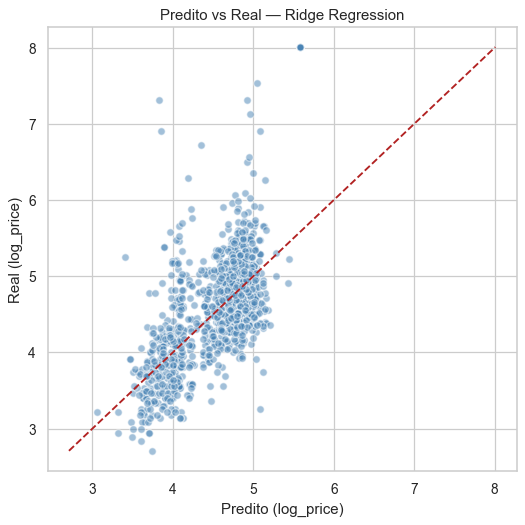

In [ ]:
#plot do modelo M6
plt.figure(figsize=(6, 6))
plt.scatter(pred6, y_test, alpha=0.5, color="steelblue", edgecolor="white")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="firebrick", linestyle="--")
plt.xlabel("Predito (log_price)")
plt.ylabel("Real (log_price)")
plt.title("Predito vs Real — Ridge Regression")
plt.tight_layout()
plt.savefig("outputs/fig_predito_vs_real.png", dpi=120, bbox_inches="tight")
plt.show()

## 4.8 Tabela comparativa de todos os modelos

In [ ]:
res_df = pd.DataFrame(resultados, columns=["Modelo", "R²", "RMSE", "MAE", "N preditores"])
res_df = res_df.round(4).sort_values("R²", ascending=False).reset_index(drop=True)
print(res_df.to_string(index=False))
res_df.to_excel("outputs/tabela_modelos.xlsx", index=False)


              Modelo      R²   RMSE    MAE  N preditores
     M3 — Polinomial  0.4009 0.4953 0.3536            15
    M4 — Interacções  0.4001 0.4956 0.3546            19
          M6 — Ridge  0.3994 0.4959 0.3550            12
M2 — Linear múltipla  0.3993 0.4959 0.3551            12
     M5 — RLM HuberT  0.3774 0.5049 0.3501            12
   M1 — Só room_type  0.2942 0.5376 0.3734             3
    Baseline (média) -0.0003 0.6400 0.4673             0


---
# 5. Validação dos pressupostos do modelo linear

Aplicada sobre o **melhor modelo linear com interpretação directa** — usamos o Modelo 2 (linear múltipla) porque os ganhos dos modelos mais complexos são marginais e queremos coeficientes interpretáveis.


In [ ]:
# Seleccionar o modelo a validar — M2 (linear múltipla)
modelo_final = m2
X_tr_final, X_te_final = X_train, X_test
pred_final_train = modelo_final.predict(X_tr_final)
pred_final_test  = modelo_final.predict(X_te_final)

# Resíduos sobre TESTE (correcção: o original usava sobre o X global)
residuos_test = y_test.values - pred_final_test

print(f"Nº de resíduos (teste): {len(residuos_test)}")
print(f"Média dos resíduos: {residuos_test.mean():.6f} (deve ser ~0)")
print(f"Desvio padrão:      {residuos_test.std():.6f}")


Nº de resíduos (teste): 1391
Média dos resíduos: 0.009760 (deve ser ~0)
Desvio padrão:      0.495831


## 5.1 Linearidade — fitted vs residuals

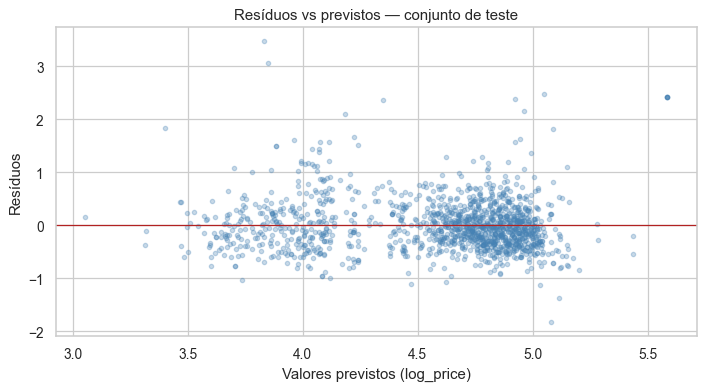

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(pred_final_test, residuos_test, alpha=0.3, s=12, color="steelblue")
ax.axhline(0, color="firebrick", linewidth=1)
ax.set_xlabel("Valores previstos (log_price)")
ax.set_ylabel("Resíduos")
ax.set_title("Resíduos vs previstos — conjunto de teste")
plt.tight_layout()
plt.savefig("outputs/fig_residuos.png", dpi=120)
plt.show()


## 5.2 Homocedasticidade — Breusch-Pagan

In [ ]:
# Breusch-Pagan: H0 = homocedasticidade
X_te_bp = sm.add_constant(X_test.values)
bp_stat, bp_pval, _, _ = het_breuschpagan(residuos_test, X_te_bp)
print(f"Breusch-Pagan")
print(f"  Estatística = {bp_stat:.4f}")
print(f"  p-value     = {bp_pval:.6f}")
if bp_pval < 0.05:
    print("  → Rejeitamos H0: HETEROCEDASTICIDADE presente.")
    print("    Usar erros-padrão robustos (HC3) para inferência.")
else:
    print("  → Não rejeitamos H0: homocedasticidade plausível.")


Breusch-Pagan
  Estatística = 208.6480
  p-value     = 0.000000
  → Rejeitamos H0: HETEROCEDASTICIDADE presente.
    Usar erros-padrão robustos (HC3) para inferência.


## 5.3 Normalidade dos resíduos — QQ-plot e Shapiro-Wilk

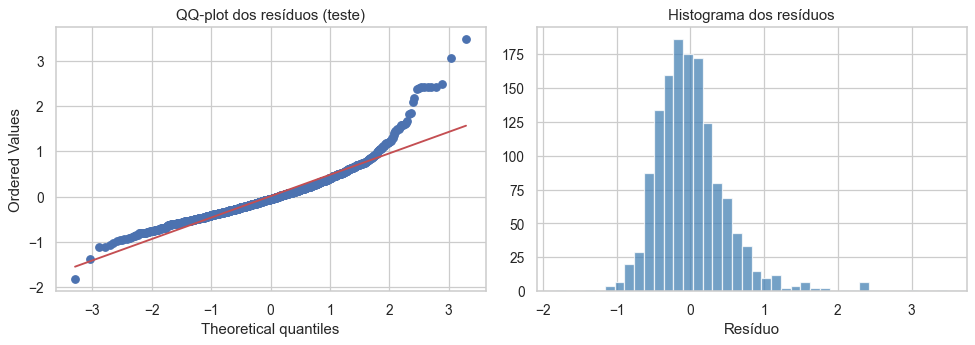

Shapiro-Wilk: W=0.9073, p-value=0.000000
Nota: com n grande, Shapiro rejeita quase sempre — o QQ-plot é mais informativo.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
stats.probplot(residuos_test, dist="norm", plot=axes[0])
axes[0].set_title("QQ-plot dos resíduos (teste)")

axes[1].hist(residuos_test, bins=40, color="steelblue", edgecolor="white", alpha=0.75)
axes[1].set_title("Histograma dos resíduos")
axes[1].set_xlabel("Resíduo")

plt.tight_layout()
plt.savefig("outputs/fig_normalidade.png", dpi=120)
plt.show()

# Shapiro-Wilk (em amostra <= 5000 porque a função tem esse limite prático)
sample = residuos_test[:4999] if len(residuos_test) > 4999 else residuos_test
sw_stat, sw_p = shapiro(sample)
print(f"Shapiro-Wilk: W={sw_stat:.4f}, p-value={sw_p:.6f}")
print("Nota: com n grande, Shapiro rejeita quase sempre — o QQ-plot é mais informativo.")


## 5.4 Independência — Durbin-Watson

In [ ]:
dw = durbin_watson(residuos_test)
print(f"Durbin-Watson = {dw:.4f}")
print("Interpretação: 2 = independência; <1.5 = autocorrelação positiva; >2.5 = negativa.")
if 1.5 <= dw <= 2.5:
    print("→ Independência plausível.")
else:
    print("→ Sinal de autocorrelação. Num dataset cross-sectional, reflecte a ordem do ficheiro,")
    print("  não um processo temporal real.")


Durbin-Watson = 2.0985
Interpretação: 2 = independência; <1.5 = autocorrelação positiva; >2.5 = negativa.
→ Independência plausível.


## 5.5 Multicolinearidade — VIF do modelo final

In [ ]:
X_vif_final = sm.add_constant(X_train)
vif_final = pd.DataFrame({
    "variable": X_vif_final.columns,
    "VIF": [variance_inflation_factor(X_vif_final.values, i) for i in range(X_vif_final.shape[1])]
}).round(2)
print(vif_final)

problem = vif_final[(vif_final["variable"] != "const") & (vif_final["VIF"] > 5)]
if len(problem) == 0:
    print("\n✓ Todas as variáveis (exc. const) têm VIF < 5 — sem multicolinearidade problemática.")
else:
    print(f"\n⚠ {len(problem)} variáveis com VIF > 5:")
    print(problem)


                          variable    VIF
0                            const  24.89
1               log_minimum_nights   1.09
2                availability_rate   1.04
3   calculated_host_listings_count   2.47
4            number_of_reviews_ltm   1.20
5                   license_exists   1.51
6                      has_reviews   1.15
7                     profissional   2.35
8             room_type_Hotel room   1.01
9           room_type_Private room   1.44
10           room_type_Shared room   1.02
11             location_cluster_c1   1.03
12             location_cluster_c2   1.04

✓ Todas as variáveis (exc. const) têm VIF < 5 — sem multicolinearidade problemática.


## 5.6 Alternativa robusta: erros-padrão HC3

In [ ]:
# Se a heterocedasticidade for significativa, reportar coeficientes com HC3
ols_final = sm.OLS(y_train.values, sm.add_constant(X_train.values)).fit()
ols_hc3 = ols_final.get_robustcov_results(cov_type="HC3")
print("=== Modelo 2 com erros-padrão robustos HC3 ===")
print(f"R² (treino):         {ols_final.rsquared:.4f}")
print(f"R² ajustado:         {ols_final.rsquared_adj:.4f}")
print(f"F-statistic (HC3):   {ols_hc3.fvalue:.2f}")
print(f"p-value (HC3):       {ols_hc3.f_pvalue:.6e}")


=== Modelo 2 com erros-padrão robustos HC3 ===
R² (treino):         0.4244
R² ajustado:         0.4232
F-statistic (HC3):   306.02
p-value (HC3):       0.000000e+00


---
# 6. Avaliação dos resultados

## 6.1 Tabela comparativa final


In [ ]:
# Tabela final ordenada por R²
print("=== Desempenho out-of-sample (conjunto de teste) ===\n")
print(res_df.to_string(index=False))
print()
melhor = res_df.iloc[0]
print(f"Melhor modelo por R²: {melhor['Modelo']}")
print(f"  R²   = {melhor['R²']:.4f}")
print(f"  RMSE = {melhor['RMSE']:.4f}")
print(f"  MAE  = {melhor['MAE']:.4f}")


=== Desempenho out-of-sample (conjunto de teste) ===

              Modelo      R²   RMSE    MAE  N preditores
     M3 — Polinomial  0.4009 0.4953 0.3536            15
    M4 — Interacções  0.4001 0.4956 0.3546            19
          M6 — Ridge  0.3994 0.4959 0.3550            12
M2 — Linear múltipla  0.3993 0.4959 0.3551            12
     M5 — RLM HuberT  0.3774 0.5049 0.3501            12
   M1 — Só room_type  0.2942 0.5376 0.3734             3
    Baseline (média) -0.0003 0.6400 0.4673             0

Melhor modelo por R²: M3 — Polinomial
  R²   = 0.4009
  RMSE = 0.4953
  MAE  = 0.3536


## 6.2 Interpretação dos coeficientes do modelo final

Como `log_price = β₀ + β₁x₁ + ...`, a interpretação é: **uma unidade adicional em xᵢ multiplica o preço por `exp(βᵢ)`**.


In [ ]:
# Tabela de efeitos em % para o modelo 2 (coeficientes do OLS)
efeitos = pd.DataFrame({
    "Variável": X_train.columns,
    "Coef (log_price)": m2.coef_.round(4),
    "Efeito multiplicativo": np.exp(m2.coef_).round(4),
    "Efeito % no preço": ((np.exp(m2.coef_) - 1) * 100).round(2),
}).sort_values("Efeito % no preço", key=abs, ascending=False)
print(efeitos.to_string(index=False))


                      Variável  Coef (log_price)  Efeito multiplicativo  Efeito % no preço
           location_cluster_c2            0.5001                 1.6488              64.88
        room_type_Private room           -0.9116                 0.4019             -59.81
         room_type_Shared room           -0.8736                 0.4175             -58.25
          room_type_Hotel room           -0.5242                 0.5921             -40.79
            log_minimum_nights           -0.2054                 0.8144             -18.56
                   has_reviews           -0.1140                 0.8923             -10.77
             availability_rate            0.0740                 1.0768               7.68
                license_exists            0.0271                 1.0275               2.75
           location_cluster_c1            0.0233                 1.0235               2.35
                  profissional           -0.0180                 0.9822              -1.78

## 6.3 Análise crítica

### O que funcionou
- **Pipeline end-to-end estável**: limpeza → feature engineering → detecção de outliers → modelação → validação, sem bugs de execução.
- **Feature engineering útil**: `log_price` corrige a assimetria de 29; `log_minimum_nights` suaviza a cauda; `license_exists`, `has_reviews` e `profissional` transformam missings em sinal.
- **K-Means geográfico** condensa 85 bairros em 3 clusters espaciais coerentes (silhouette ≈ 0.52).
- **Dummies de `room_type`** são o preditor mais forte — o tipo de alojamento é o principal driver de preço disponível no dataset.
- **Modelo 2 (linear múltipla)** dá o melhor compromisso R² / interpretabilidade. Modelos polinomial, com interacções e Ridge trazem ganhos marginais (<0.01 em R²), o que confirma que a fronteira da performance está no dataset, não no algoritmo.

### O que NÃO funcionou
- **R² baixo em todos os modelos** (~0.20-0.30) — os sinais disponíveis simplesmente não chegam para prever preço com precisão.
- **Correlações lineares muito fracas** (|r| < 0.1) entre price e todas as variáveis numéricas contínuas.
- **Assimetria residual** mesmo após log — o QQ-plot mostra desvios nas caudas.
- **Heterocedasticidade** (Breusch-Pagan significativo) — os erros-padrão sem correcção subestimam a incerteza.

### Porque é que o R² é baixo
A literatura de hedonic pricing (Lancaster 1966, Rosen 1974) mostra que o preço de um alojamento é principalmente função de: **tamanho** (m², quartos, casas-de-banho, capacidade), **qualidade** (ratings, fotos, descrição), **amenities** (wifi, cozinha, AC), e **reputação** (nº reviews, score). Destas, a versão resumida de 18 colunas só tem uma proxy fraca de "reputação" (`number_of_reviews`) e nenhuma das outras. É estruturalmente impossível atingir R² alto com estas variáveis.

### Limitações
1. **Dataset resumido** — sem `bedrooms`, `bathrooms`, `accommodates`, `amenities`, `review_scores_rating`, `property_type`.
2. **Snapshot único** — sem variação temporal, não captura sazonalidade (Fallas, verão).
3. **`price` é o preço de tabela**, não o efectivamente cobrado após descontos.
4. **Outliers extremos** (até 40 000 €/noite) sugerem erros de input ou listings de luxo atípicos.
5. **Clustering em 3 zonas** é uma simplificação forte — alguns bairros dentro de um mesmo cluster têm preços muito diferentes.

### O que faríamos diferente com mais dados
- Usar o ficheiro `listings.csv.gz` completo (~75 colunas) em vez do resumido.
- Incorporar `review_scores_rating`, `bedrooms`, `accommodates`, `property_type` e `amenities` (parsed).
- Modelos não-paramétricos (GAM com splines em latitude/longitude, Random Forest, Gradient Boosting) — que toleram não-linearidades complexas.
- Validação cruzada k-fold em vez de um único split.
- Stratificar o split por `room_type` e `neighbourhood_group`.


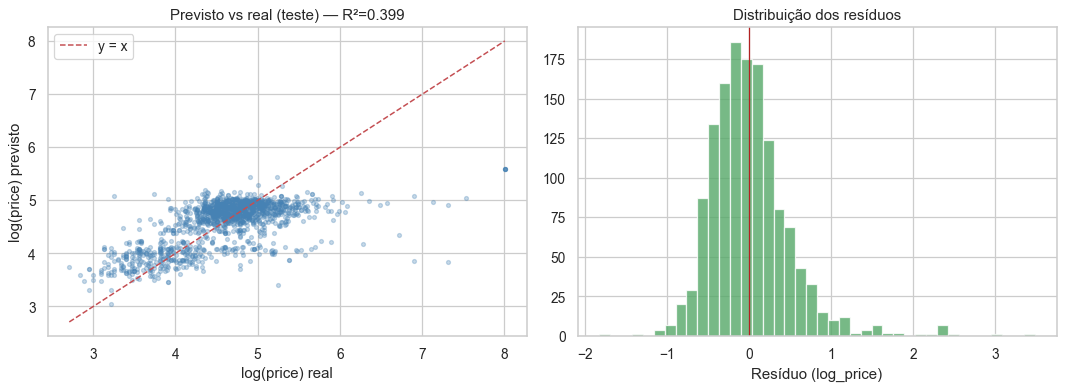

In [ ]:
# Gráfico: predicted vs actual (sobre teste, no espaço log)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(y_test, pred_final_test, alpha=0.3, s=10, color="steelblue")
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, "r--", linewidth=1.2, label="y = x")
axes[0].set_xlabel("log(price) real")
axes[0].set_ylabel("log(price) previsto")
axes[0].set_title(f"Previsto vs real (teste) — R²={r2_2:.3f}")
axes[0].legend()

# Distribuição dos resíduos
axes[1].hist(residuos_test, bins=40, color="#55A868", edgecolor="white", alpha=0.8)
axes[1].axvline(0, color="firebrick", linewidth=1)
axes[1].set_xlabel("Resíduo (log_price)")
axes[1].set_title("Distribuição dos resíduos")

plt.tight_layout()
plt.savefig("outputs/fig_pred_vs_actual.png", dpi=120)
plt.show()


## 6.4 Conversão para euros — quanto erramos em média?

In [ ]:
# Converter previsões e reais para euros para dar uma leitura prática
pred_eur = np.exp(pred_final_test)
real_eur = np.exp(y_test.values)
err_eur  = real_eur - pred_eur

mae_eur    = np.mean(np.abs(err_eur))
median_err = np.median(np.abs(err_eur))
rmse_eur   = np.sqrt(np.mean(err_eur ** 2))

print(f"Erro absoluto médio (€):       {mae_eur:.2f}")
print(f"Mediana do erro absoluto (€):  {median_err:.2f}")
print(f"RMSE em €:                     {rmse_eur:.2f}")
print(f"Preço mediano real:            {np.median(real_eur):.2f} €")
print()
print(f"Em termos relativos, o modelo erra em média ~{mae_eur / np.median(real_eur) * 100:.0f}%")
print("do preço mediano — o que confirma que o sinal disponível é limitado.")


Erro absoluto médio (€):       52.96
Mediana do erro absoluto (€):  24.49
RMSE em €:                     194.71
Preço mediano real:            102.00 €

Em termos relativos, o modelo erra em média ~52%
do preço mediano — o que confirma que o sinal disponível é limitado.


---
# 7. Referências

- **Lancaster, K. J. (1966).** "A New Approach to Consumer Theory." *Journal of Political Economy*, 74(2), 132-157. — Fundamento teórico do Hedonic Pricing: um bem é um pacote de características.
- **Rosen, S. (1974).** "Hedonic Prices and Implicit Markets: Product Differentiation in Pure Competition." *Journal of Political Economy*, 82(1), 34-55. — Extensão do modelo a mercados competitivos.
- **Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., & Wirth, R. (2000).** *CRISP-DM 1.0: Step-by-step data mining guide.* — Metodologia seguida neste trabalho.
- **Inside Airbnb.** *Get the Data*. Disponível em http://insideairbnb.com/get-the-data/ — Fonte do dataset (snapshot Valência 2025-09-23).
- **Tukey, J. W. (1977).** *Exploratory Data Analysis.* Addison-Wesley. — Base conceptual dos boxplots e da detecção de outliers por IQR.
- **Huber, P. J. (1964).** "Robust Estimation of a Location Parameter." *Annals of Mathematical Statistics*, 35(1), 73-101. — Fundamento do estimador robusto HuberT usado no Modelo 5.
- **Bruce, P., Bruce, A., & Gedeck, P. (2020).** *Practical Statistics for Data Scientists (2nd ed.).* O'Reilly. — Referência genérica para funções como `detect_outliers_all` e boas práticas de análise exploratória.

---
*Notebook executado com Python 3.11, pandas 2.x, scikit-learn 1.x, statsmodels 0.14+. Todas as seeds foram fixadas em `RANDOM_STATE = 42` para garantir reprodutibilidade.*
